In [1]:
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask


print(f"[Line {inspect.currentframe().f_lineno}] ...  Done with cell. ")

[Line 13] n_cols in ConstantObjects: 21
[Line 15] n_cols: 21, n_rows: 18
[Line 26] n_cols in ConstantObjects: 21
[Line 28] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

In [2]:
import pandas as pd
import importlib
import rasterio
import Utils 
import numpy as np
import Constants
import ConstantObjects
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect
import os
from rasterio.mask import mask

from IPython.display import display, HTML
display(HTML("<style>.jp-OutputArea {max-height: 200px}</style>"))


rows = []  # collect per-date stats here
#good dates in veracruz are 2024-01-13, 2025-01-12
startDate = "2022-01-03"
#startDate = "2022-05-18"

#startDate = "2025-01-12"


endDate = "2025-07-31"

#endDate = "2025-08-16"
#endDate = "2022-12-31"


#endDate = "2022-12-31" # temporarily


# Villanueva, VER
#startDate = "2025-01-12"
#endDate = "2025-08-16"
#ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"
#bogus
#startDate = "2021-10-01"
#endDate = "2021-10-01"

dates = Utils.generate_date_range(startDate, endDate,  "%Y-%m-%d", 5)
#datesIncrementDaily = Utils.generate_date_range(startDate, endDate,  "%Y-%m-%d", 1)
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")


                                 
#dates = Utils.generate_date_range("2025-06-16", "2025-06-17",  "%Y-%m-%d", 5)

# jan 12, no cloud directly over farm.
#Feb 11, lots of clouds over farm
ndmi_tile_tif=""
print(f"Cell [Line {inspect.currentframe().f_lineno}] ... dates = ",dates)
        
for date in dates:
    
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date = ",date)
    gndvi_tile_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "gndvi","tif")
    ndmi_tile_tif  = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi", "tif")
    rgb_tile_tif   = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb.uint8","tif")

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ndmi_tile_tif = ",ndmi_tile_tif)
    gdf_box = ConstantObjects.gdf_box_terreno_casa
    ndmi_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "ndmi-terreno-casa","tif")
    ndmi_plots_2_3_1A_1B_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "plots_2_3_1A_1B","tif")
    ndmi_casa_y_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "casa_y_vecino","tif")
    #ndmi_milpa_vecino_tif  = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "milpa_vecino","tif")

    b02_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B02","jp2")
    b03_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B03","jp2")
    b04_terreno_casa_jp2 = Utils.make_path_name("s2_point_series", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "B04","jp2")
    if os.path.exists(b02_terreno_casa_jp2) and os.path.exists(b03_terreno_casa_jp2) and os.path.exists(b04_terreno_casa_jp2):
        print(f"[Line {inspect.currentframe().f_lineno}] ... found all three of B02,B03, and B04 .jp2 images. Moving forward. ")
    else:
        print(f"[Line {inspect.currentframe().f_lineno}] ... will have to try the next date, because unable to find files:  ", b02_terreno_casa_jp2 ," , " , b03_terreno_casa_jp2," , " , b04_terreno_casa_jp2  )
        continue #If we do not have all three files for this date we should move on to the next date.
    green_vs_red_blue = np.nan
    rgb_terreno_casa_tif = Utils.make_path_name("s2_parcel_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date, "rgb-terreno-casa","tif")

    print(f"[Line {inspect.currentframe().f_lineno}] ... ndmi_terreno_casa_tif = ",ndmi_terreno_casa_tif)

    
    #cloud_terreno_casa = Utils.estimate_cloud_fraction_rgb_over_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa,treat_zero_as_nodata=True)
    # add up red intensity
    b2_intensity_terreno_casa = Utils.crop_and_sum_intensity(b02_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b3_intensity_terreno_casa = Utils.crop_and_sum_intensity(b03_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b4_intensity_terreno_casa = Utils.crop_and_sum_intensity(b04_terreno_casa_jp2, ConstantObjects.gdf_box_terreno_casa, scale_factor=None, clip_to_aoi_bounds=True)
    b2_norm_reflectance_terreno_casa = b2_intensity_terreno_casa["sum"]/b2_intensity_terreno_casa["valid_pixels"]
    b3_norm_reflectance_terreno_casa = b3_intensity_terreno_casa["sum"]/b3_intensity_terreno_casa["valid_pixels"]
    b4_norm_reflectance_terreno_casa = b4_intensity_terreno_casa["sum"]/b4_intensity_terreno_casa["valid_pixels"]
    red_green_blue_average = (b2_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa+b3_norm_reflectance_terreno_casa)/3 
    #SCF continue here..
    cloudy =0
    if (red_green_blue_average) > 1650:  cloudy = 1

    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_terreno_casa, ndmi_terreno_casa_tif) ")
    stats_terreno_casa = {
        "count_valid": 0,
        "mean": float("nan"),
        "median": float("nan"),
    }
    stats_casa_y_vecino = stats_terreno_casa

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")
    if not cloudy: stats_casa_y_vecino  = Utils.crop_ndmi_to_gdf(ndmi_tile_tif, ConstantObjects.gdf_box_casa_y_vecino , ndmi_casa_y_vecino_tif)  

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... ")

    print("Avg NDMI over AOI plots 4,5:", stats_casa_y_vecino["mean"])
  
    print(f"[Line {inspect.currentframe().f_lineno}] ...  ")
        
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    ndmi_plots_4_5_stats       =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      ndmi_tile_tif, "ndmi_plots_4_5",       date, cloudy)
    ndmi_plots_2_3_1A_1B_stats =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,ndmi_tile_tif, "ndmi_plots_2_3_1A_1B", date, cloudy)
    ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
    #ndmi_milpa1_stats=            Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa1,ndmi_tile_tif,"ndmi_milpa1",date, cloudy)
    ndmi_milpa_vecino_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,   ndmi_tile_tif, "ndmi_milpa_vecino",    date, cloudy)
    ndmi_terreno_casa_stats    =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_terreno_casa,   ndmi_tile_tif, "ndmi_terreno_casa",    date, cloudy)
    gndvi_plots_4_5_stats      =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_4_5,      gndvi_tile_tif,"gndvi_plots_4_5",      date, cloudy)
    gndvi_plots_2_3_1A_1B_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B,gndvi_tile_tif,"gndvi_plots_2_3_1A_1B",date, cloudy)
    #gndvi_milpa1_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa1,gndvi_tile_tif,"gndvi_milpa1",date, cloudy)
    gndvi_milpa1_stats=  Utils.get_stats_from_gdf(ConstantObjects.gdf_plotMilpa1,gndvi_tile_tif,"gndvi_milpa1",date, cloudy)

    gndvi_milpa_vecino_stats   =  Utils.get_stats_from_gdf(ConstantObjects.gdf_box_milpa_vecino,gndvi_tile_tif,"gndvi_milpa_vecino",date, cloudy)

    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... date  ",date)
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_4_5_stats.get(mean,   np.nan) = ",gndvi_plots_4_5_stats.get("mean",   np.nan))
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... gndvi_plots_2_3_1A_1B_stats.get(mean,   np.nan) = ",gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan))

    #gndvi_reference = gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan)
    #ndmi_reference  = ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan)
    gndvi_reference = gndvi_milpa_vecino_stats.get("mean",   np.nan)
    ndmi_reference  = ndmi_milpa_vecino_stats.get("mean",   np.nan)
    
    rows.append({
        "date": date,
        "ndmi_terreno_casa":      ndmi_terreno_casa_stats.get("mean", np.nan),
        # Now making measurements relative to milpa_vecino
        "gndvi_plots_4_5":        gndvi_plots_4_5_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_plots_2_3_1A_1B":  gndvi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-gndvi_reference,
        "gndvi_milpa1":           gndvi_milpa1_stats.get("mean",   np.nan)-gndvi_reference,

        "gndvi_milpa_vecino":     gndvi_milpa_vecino_stats.get("mean",   np.nan)-gndvi_reference,
        
        "ndmi_plots_4_5":         ndmi_plots_4_5_stats.get ("mean",   np.nan)-ndmi_reference,
        "ndmi_plots_2_3_1A_1B":   ndmi_plots_2_3_1A_1B_stats.get("mean",   np.nan)-ndmi_reference,
        "ndmi_milpa1":            ndmi_milpa1_stats.get("mean",   np.nan)-ndmi_reference,

        "ndmi_milpa_vecino":      ndmi_milpa_vecino_stats.get("mean",   np.nan)-ndmi_reference,
        
        "red": b2_norm_reflectance_terreno_casa,
        "green": b3_norm_reflectance_terreno_casa,
        "blue": b4_norm_reflectance_terreno_casa,
        "red_green_blue_average": red_green_blue_average,
        "cloudy" : cloudy *1

    })    
    print(f"[Line {inspect.currentframe().f_lineno}] ... Just appended to rows, an entry with date = ",date)
    print(f"[Cell Line {inspect.currentframe().f_lineno}] ... b2_intensity_terreno_casa[sum]  ",b2_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b3_intensity_terreno_casa[sum]  ",b3_intensity_terreno_casa["sum"])
    print(f"Cell [Line {inspect.currentframe().f_lineno}] ... b4_intensity_terreno_casa[sum]  ",b4_intensity_terreno_casa["sum"])
    #print(f"Cell [Line {inspect.currentframe().f_lineno}] ... stats_milpa_vecino.get(mean,   np.nan)  ",stats_milpa_vecino.get("mean",   np.nan))

    #Utils.show_ndmi_moist(ndmi_terreno_casa_tif, scale=12)
    print(f"[Line {inspect.currentframe().f_lineno}] ... calling Utils.crop_ndmi_to_gdf(rgb_tile_tif, ConstantObjects.gdf_box_terreno_casa, rgb_terreno_casa_tif)  ")
 
    #Utils.show_tif_fit(rgb_terreno_casa_tif, scale=12, cmap="gray")
    print(f"[Line {inspect.currentframe().f_lineno}] ... ")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")

[Line 13] n_cols in ConstantObjects: 21
[Line 15] n_cols: 21, n_rows: 18
[Line 26] n_cols in ConstantObjects: 21
[Line 28] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

[Line 48] ...   
Cell [Line 57] ... dates =  ['2022-01-03', '2022-01-08', '2022-01-13', '2022-01-18', '2022-01-23', '2022-01-28', '2022-02-02', '2022-02-07', '2022-02-12', '2022-02-17', '2022-02-22', '2022-02-27', '2022-03-04', '2022-03-09', '2022-03-14', '2022-03-19', '2022-03-24', '2022-03-29', '2022-04-03', '2022-04-08', '2022-04-13', '2022-04-18', '2022-04-23', '2022-04-28', '2022-05-03', '2022-05-08', '2022-05-13', '2022-05-18', '2022-05-23', '2022-05-28', '2022-06-02', '2022-06-07', '2022-06-12', '2022-06-17', '2022-06-22', '2022-06-27', '2022-07-02', '2022-07-07', '2022-07-12', '2022-07-17', '2022-07-22', '2022-07-27', '2022-08-01', '2022-08-06', '2022-08-11', '2022-08-16', '2022-08-21', '2022-08-26', '2022-08-31', '2022-09-05', '2022-09-10', '2022-09-15', '2022-09-20', '2022-09-25', '2022-09-30', '2022-10-05', '2022-10-10', '2022-10-15', '2022-10-20', '2022-10-25', '2022-10-30', '2022-11-04', '2022-11-09', '2022-11-14', '2022-11-19', '2022-11-24', '2022-11-29', '2022-12-04', '2

In [3]:
importlib.reload(Utils)

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)    

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)

df["date"] = pd.to_datetime(df["date"]).dt.normalize()

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. df = ",df)


df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#df = pd.DataFrame(rows)
print(df.columns.tolist())
print(df.head())
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#Borana University, Ethiopia
#startDate = "2021-10-01"
#endDate = "2022-06-30"

def to_mx_date(col):
    return pd.to_datetime(col, utc=True).dt.tz_convert("America/Mexico_City").dt.normalize()

# --- existing: rows -> df (sparse NDMI/Cloud dates)
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values("date")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
precip_df = Utils.daily_precip_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)
temp_df = Utils.daily_temp_openmeteo(Constants.lat0, Constants.lon0, startDate, endDate)

api_key = "E6RKNQ36BSLC8EUK5S3C5AKUQ"
location = str(Constants.lat0)+","+str(Constants.lon0) #"19.777411,-96.870102"  # Change location as needed
unit_group = "metric" 

visualcrossing_dict = Utils.fetch_weather_data(api_key, location, startDate, endDate, unit_group)

print ("**********************")
counter=0
#visualcrossing_array = np.array([][])
if visualcrossing_dict:
    # Print sample data
    for day in visualcrossing_dict['days']:
        #print(f"Date: {day['datetime']}, Temperature: {day['temp']} °C, Precipitation: {day['precip']} mm")
        #visualcrossing_array[counter][0] = day['datetime']
        #visualcrossing_array[counter][1] = day['temp']
        #visualcrossing_array[counter][2] = day['precip']
        counter += 1
#print ("visualcrossing_array = ",visualcrossing_array)
#for i in arange(counter):
    #print(" i = ",i," datetime = ",visualcrossing_array[i][0])
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

precip_df.head()
print(f"[Line {inspect.currentframe().f_lineno}] ...   ")

print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")
p = precip_df.copy()
p["date"] = p["date"].dt.tz_localize(None)
#p["date"] = pd.to_datetime(p["date"]).dt.normalize()
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

t = temp_df.copy()
t["date"] = pd.to_datetime(t["date"]).dt.tz_localize(None)
#t["date"] = pd.to_datetime(t["date"]).dt.normalize()
p = p.merge(t, on="date", how="left").sort_values("date")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#p = p.sort_values("date")

# align daily precip with sparse NDMI, for excel:
out = p.merge(df, on="date", how="left")
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

# save for Excel
out.to_csv("daily_table.csv", index=False)
# or
# out.to_excel("daily_table.xlsx", index=False)
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. Done with cell! ")


[Cell Line 6] .. df =             date  ndmi_terreno_casa  gndvi_plots_4_5  gndvi_plots_2_3_1A_1B  \
0    2022-01-03                NaN              NaN                    NaN   
1    2022-01-08           0.042235         0.106388               0.016433   
2    2022-01-13                NaN              NaN                    NaN   
3    2022-01-18           0.056051        -0.038229              -0.022703   
4    2022-01-23          -0.020437         0.049109               0.024126   
..          ...                ...              ...                    ...   
254  2025-07-11                NaN              NaN                    NaN   
255  2025-07-16           0.146467        -0.009356              -0.094765   
256  2025-07-21                NaN              NaN                    NaN   
257  2025-07-26                NaN              NaN                    NaN   
258  2025-07-31                NaN              NaN                    NaN   

     gndvi_milpa1  gndvi_milpa_vecino  n

for plot  gndvi_plots_4_5  my_plot_std_dev =  0.025847002581690072
[Cell Line 18] .. my_plot_avg=  -0.021664161015959346
SSEDA = [(Timestamp('2025-03-01 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-04-30 12:00:00'))]
for plot  gndvi_plots_4_5  my_plot_std_dev =  0.013214759229697528
[Cell Line 18] .. my_plot_avg=  -0.009783311109793814
0 start, end, middle dates:  2024-03-01 00:00:00 2024-06-30 00:00:00 2024-04-30 12:00:00
 value  -0.009783311109793814
1 start, end, middle dates:  2025-03-01 00:00:00 2025-06-30 00:00:00 2025-04-30 12:00:00
 value  -0.021664161015959346
SSEDA = [(Timestamp('2024-03-01 00:00:00'), Timestamp('2024-06-30 00:00:00'), Timestamp('2024-04-30 12:00:00')), (Timestamp('2025-03-01 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-04-30 12:00:00'))]
for plot  gndvi_plots_4_5  my_plot_std_dev =  0.025912805363241174
[Cell Line 18] .. my_plot_avg=  -0.03843597103567684
0 start, end, middle dates:  2023-03-01 00:00:00 2023-06-30 00:00:00 2

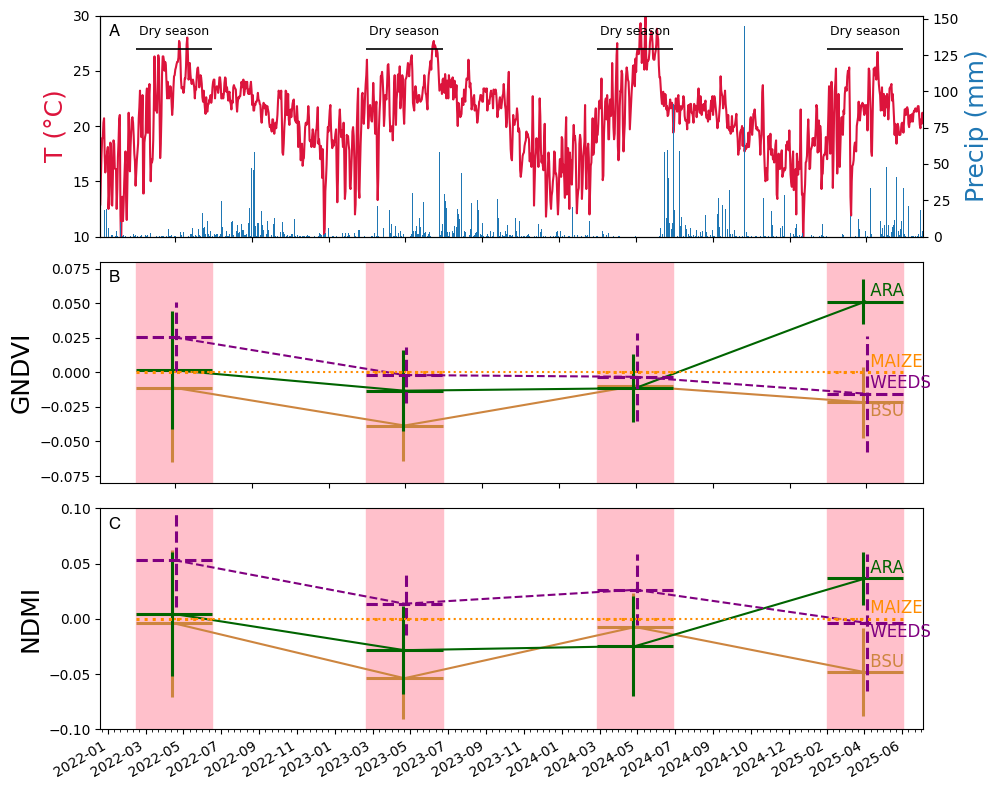

Area of Weeds =  0    8095.203644
dtype: float64  << 
Area of Milpa2 =  0    2623.766942
dtype: float64  << 
Area of terreno_casa =  0    6759.659362
dtype: float64  << 
Area of ARA =  0    1192.881075
dtype: float64  << 
Area of BSU =  0    397.627025
dtype: float64  << 
Area of MAIZE =  0    7097.642656
dtype: float64  << 
in units of :  metre


In [6]:
import MatPlotLibUtils
importlib.reload(MatPlotLibUtils)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, HTML
import importlib
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(MatPlotLibUtils)
import  datetime as _dt
from datetime import datetime, timedelta
import pandas
import geopandas as gpd


#startDate = "2025-01-03"

#warmDryStart2025 = pandas.to_datetime("2025-03-15")
#warmDryEnd2025   = pandas.to_datetime("2025-05-18") 


display(HTML("<style>.jp-OutputArea {max-height: 20000px;min_height: 20000px;}</style>"))

# --- colors for consistency
precip_color = "tab:blue"
temperature_color   = "crimson"

# --- plot: NDMI (left), cloud (right), DAILY precip on a second right axis
fig, axes = plt.subplots(3,figsize=(10, 8))
# NDMI lines (sparse dates)
#ax.set_ylim(.1, .47)
ax=axes[0]


minTemp = 10
maxTemp = 30
myfontsize = 18
#ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
#ax.bar(df["date"], df["cloudy"].fillna(0)*maxTemp,color="lightgrey",
#        width=pd.Timedelta("5D"), alpha=0.3, label="Cloudy")
ax.set_ylim(minTemp, maxTemp)
ax.spines["right"].set_position(("axes", 1.10))  # shift outward
p["tave_10d"] = p["tavg"].rolling(window=10, min_periods=1).mean()
#ax.plot(visualcrossing_dict['datetime'], visualcrossing_dict["temp"],lw=1.5, label="T (°C)") 
dates = [datetime.strptime( day['datetime'], "%Y-%m-%d") for day in visualcrossing_dict['days']]
temperatures = [day['temp'] for day in visualcrossing_dict['days']]
precipitations = [day['precip'] for day in visualcrossing_dict['days']]
ax.plot(dates, temperatures,lw=1.5, label="T (°C)",color=temperature_color) 
#ax.plot(p["date"], p["tave_10d"],color=temperature_color, lw=1.5, label="T 10-day back-average (°C)") # takes min,max, avg
ax.set_ylabel("T (°C)",color=temperature_color,fontsize = myfontsize)

ax.grid(False)
#ax.set_ylabel("NDMI")
#ax.legend(loc="upper center")
ax.set_frame_on(True); ax.patch.set_visible(False)
MatPlotLibUtils.indicate_seasons(startDate,endDate, ax,"Dry season")

ax2 = ax.twinx()
ax2.set_ylabel("Precip (mm)",color=precip_color,fontsize = myfontsize)
# Precip (second right axis; ALL daily bars)
#ax2.bar(p["date"], p["precip_mm"].fillna(0), width=pd.Timedelta("0.85D"), alpha=0.3, label="Precip (mm)",color=precip_color)
ax2.bar(dates, precipitations,label="Precipitation (mm)",color=precip_color)

axes[2].set_ylabel("NDMI",fontsize = myfontsize)
#axes[2].set_ylabel("NDMI (Moisture)",fontsize = myfontsize)

ymin=-0.1
ymax=.1
axes[1].set_ylim(-.08, .08) 
axes[2].set_ylim(-.1, .1)
MatPlotLibUtils.indicate_seasons_box(startDate,endDate , axes[1],my_label="Dry season",my_color="pink",line_style="none")
MatPlotLibUtils.indicate_seasons_box(startDate,endDate,  axes[2],my_label="Dry season",my_color="pink",line_style="none")


axes[1].set_ylabel("Vegetation",fontsize = myfontsize)
axes[1].set_ylabel("GNDVI",fontsize = myfontsize)

#axes[1].set_ylim([-.1, .1])
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_plots_4_5",      axes[1],"peru","solid","BSU",-3,"top")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_plots_2_3_1A_1B",axes[1],"darkgreen","solid","ARA",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_milpa1"  ,       axes[1],"purple","dashed","WEEDS",3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"gndvi_milpa_vecino",   axes[1],"darkorange","dotted","MAIZE",0,"center")

#stat sig difference between +-COVER
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_plots_4_5"      ,axes[2],"peru",     "solid","BSU",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_plots_2_3_1A_1B",axes[2],"darkgreen",    "solid","ARA",-3,"center")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_milpa1"         ,axes[2],"purple",    "dashed","WEEDS",3,"top")
MatPlotLibUtils.plot_season_averages(startDate,endDate,df,"ndmi_milpa_vecino"   ,axes[2],"darkorange","dotted","MAIZE",0,"center")

# Align x-limits to cover full  range too
xmin = min(df["date"].min(), p["date"].min())
xmax = max(df["date"].max(), p["date"].max())
axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)
axes[2].set_xlim(xmin, xmax)

axes[2].xaxis.set_minor_locator(mdates.DayLocator(interval=10))   # tick every 5 days
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=60)) 
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

axes[0].annotate("A", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[1].annotate("B", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
axes[2].annotate("C", xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top', fontfamily='helvetica', bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))


fig.autofmt_xdate()
fig.tight_layout()
plt.show()
fig.savefig("ndmi_temp_precipitation_plot.png", dpi=300, bbox_inches="tight")

print ("Area of Weeds = ", (ConstantObjects.gdf_plotMilpa1.to_crs(epsg=3395)).area, " << ")
print ("Area of Milpa2 = ", (ConstantObjects.gdf_plotMilpa2.to_crs(epsg=3395)).area, " << ")
print ("Area of terreno_casa = ", (ConstantObjects.gdf_box_terreno_casa.to_crs(epsg=3395)).area, " << ")
print ("Area of ARA = ", (ConstantObjects.gdf_box_plots_2_3_1A_1B.to_crs(epsg=3395)).area, " << ")
print ("Area of BSU = ", (ConstantObjects.gdf_box_plots_4_5.to_crs(epsg=3395)).area, " << ")

print ("Area of MAIZE = ", (ConstantObjects.gdf_box_milpa_vecino.to_crs(epsg=3395)).area, " << ")

print ("in units of : ",(ConstantObjects.gdf_plotMilpa1.to_crs(epsg=3395)).crs.axis_info[0].unit_name)


In [51]:
importlib.reload(Utils)

print('****************** GNDVI')
Utils.compute_season_stat_significance(Constants.warmDryStart2025,Constants.warmDryEnd2025,df,"gndvi_plots_4_5","gndvi_plots_2_3_1A_1B")
Utils.compute_season_stat_significance(Constants.warmDryStart2025,Constants.warmDryEnd2025,df,"gndvi_plots_2_3_1A_1B","gndvi_milpa1")
Utils.compute_season_stat_significance(Constants.warmDryStart2025,Constants.warmDryEnd2025,df,"gndvi_plots_2_3_1A_1B","gndvi_milpa_vecino")

print('****************** NDMI')
Utils.compute_season_stat_significance(Constants.warmDryStart2025,Constants.warmDryEnd2025,df,"ndmi_plots_2_3_1A_1B","ndmi_plots_4_5") #-COVER vs +COVER
Utils.compute_season_stat_significance(Constants.warmDryStart2025,Constants.warmDryEnd2025,df,"ndmi_plots_2_3_1A_1B","ndmi_milpa1") #+COVER vs Weeds
Utils.compute_season_stat_significance(Constants.warmDryStart2025,Constants.warmDryEnd2025,df,"ndmi_plots_2_3_1A_1B","ndmi_milpa_vecino") #+COVER vs Maize
Utils.compute_season_stat_significance(Constants.warmDryStart2025,Constants.warmDryEnd2025,df,"ndmi_plots_4_5","ndmi_milpa_vecino") #-COVER vs Maize
# Compute ARA ndmi for 2025 vs. the sum of 2022-2024 warm-dry seasons:
Utils.compute_current_vs_past_seasons_single_plot_stat_significance(2024, 2024, 2025, 3, 1, 6, 30, df, "ndmi_plots_2_3_1A_1B") #Code is not complete yet
Utils.compute_current_vs_past_seasons_single_plot_stat_significance(2024, 2024, 2025, 3, 1, 6, 30, df, "gndvi_plots_2_3_1A_1B") #Code is not complete yet
Utils.compute_current_vs_past_seasons_single_plot_stat_significance(2023, 2023, 2025, 3, 1, 6, 30, df, "gndvi_plots_2_3_1A_1B") #Code is not complete yet



****************** GNDVI
****************************
For quantities :  gndvi_plots_4_5 ,  gndvi_plots_2_3_1A_1B  report of difference between  2025-03-01 00:00:00  and  2025-06-30 00:00:00
std dev for  gndvi_plots_4_5  =  0.025847002581690072
std dev for  gndvi_plots_2_3_1A_1B  =  0.01655193275523283
Mean value of  gndvi_plots_4_5  over date range =  -0.021664161015959346
Mean value of  gndvi_plots_2_3_1A_1B  over date range =  0.05127325303414289
difference between  gndvi_plots_4_5  and  gndvi_plots_2_3_1A_1B  =  0.07293741405010223
std dev for difference  =  0.030692572723570153
Z =  2.3763864537198094
p value =  0.008741570669987722
****************************
****************************
For quantities :  gndvi_plots_2_3_1A_1B ,  gndvi_milpa1  report of difference between  2025-03-01 00:00:00  and  2025-06-30 00:00:00
std dev for  gndvi_plots_2_3_1A_1B  =  0.01655193275523283
std dev for  gndvi_milpa1  =  0.04204968944086194
Mean value of  gndvi_plots_2_3_1A_1B  over date range =

np.float64(0.02822872032826702)

In [47]:
0.04770411215704349

0.04770411215704349